**Name:** *Muhammad Bilal*

**Department:** *Data Science*

**University:** *Ghulam Ishaq Khan Institute of Engineering and Sciences*

# **Decode Labs Internship**

I used a Python Notebook since that is the medium I am most familiar with in terms of working with datasets and the tasks that need to be performed in the projects.

This notebook covers both projects from Week 1 which contains tasks 1-3 and Week 2 which contains further tasks 4 & 5 (alongside task 1 where we load the data set) that are provided in the project pdf.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('mymoviedb (1).csv', engine='python', on_bad_lines='skip')

print("Data loaded successfully!")

Data loaded successfully!


## **Week 1 Project**

### **Task 1:** Data Collection & Dataset Understanding
**Goal:** Collect or load a dataset and understand its structure.

In [6]:
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")

print("--- Column Data Types ---")
print(df.dtypes)

print("\n--- First 3 Rows ---")
display(df.head(3))

print("\nDataset Description:")
print("This dataset contains metadata about movies, including their release dates, \ntitles, overviews, popularity scores, vote counts, average votes, original language, \ngenres, and poster URLs. It represents user-generated ratings and audience \nengagement metrics.")

Dataset Shape: 9837 rows and 9 columns

--- Column Data Types ---
Release_Date          object
Title                 object
Overview              object
Popularity           float64
Vote_Count            object
Vote_Average          object
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object

--- First 3 Rows ---


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...



Dataset Description:
This dataset contains metadata about movies, including their release dates, 
titles, overviews, popularity scores, vote counts, average votes, original language, 
genres, and poster URLs. It represents user-generated ratings and audience 
engagement metrics.


### **Task 2:** Data Cleaning & Preprocessing
**Goal:** Prepare the dataset for analysis by cleaning and organizing data.

In [7]:
print(f"Duplicates before cleaning: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# We coerce critical columns to numeric (forces errors to become NaN)
cols_to_numeric = ['Popularity', 'Vote_Count', 'Vote_Average']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# We fill missing textual data with placeholders
df.fillna({'Overview': 'No overview provided', 'Genre': 'Unknown'}, inplace=True)

# We drop rows where crucial numeric targets are missing
df.dropna(subset=cols_to_numeric, inplace=True)

print(f"\nClean Dataset Shape: {df.shape}")
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Duplicates before cleaning: 0

Clean Dataset Shape: (9826, 9)

Missing values after cleaning:
Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64


### **Task 3:** Exploratory Data Analysis (EDA)
**Goal:** Analyze the dataset to discover patterns and trends.

In [8]:
# We calculate and display basic statistics for numerical columns
stats = df[['Popularity', 'Vote_Count', 'Vote_Average']].describe()
display(stats)

print("\nKey Findings:")
print("- The median Vote Average is roughly 6.5, showing most movies are rated positively.")
print("- Popularity has extreme outliers (max is over 5000 while the 75th percentile is only ~35).")

,Popularity,Vote_Count,Vote_Average
count,9826.000000,9826.000000,9826.000000
mean,40.323951,1392.943721,6.439467
std,108.879332,2611.303856,1.129797
min,13.354000,0.000000,0.000000
25%,16.128250,146.000000,5.900000
50%,21.195000,444.000000,6.500000
75%,35.179250,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000



Key Findings:
- The median Vote Average is roughly 6.5, showing most movies are rated positively.
- Popularity has extreme outliers (max is over 5000 while the 75th percentile is only ~35).


## **Week 2 Project**

### **Task 4:** Data Visualization
**Goal:** Create visual representations to communicate insights clearly.

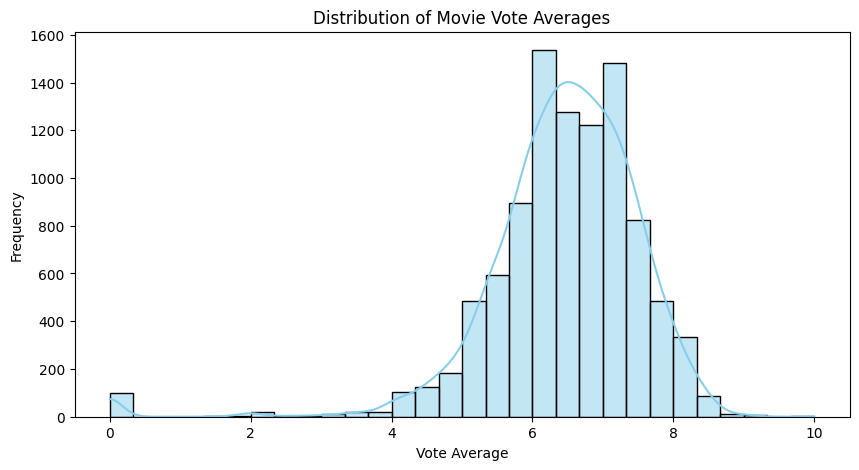

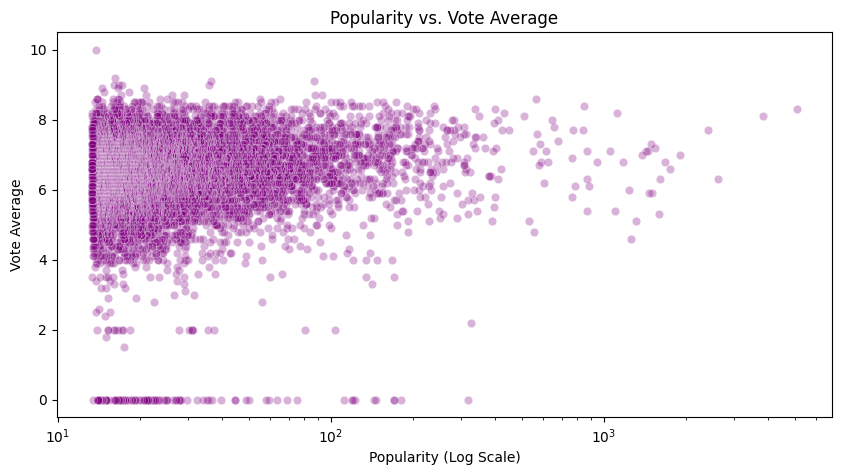

In [9]:
# 1. Distribution of Vote Average
plt.figure(figsize=(10, 5))
sns.histplot(df['Vote_Average'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Movie Vote Averages')
plt.xlabel('Vote Average')
plt.ylabel('Frequency')
plt.show()

# 2. Popularity vs Vote Average
plt.figure(figsize=(10, 5))
# Using a log scale for Popularity because of the extreme outliers found in Task 3
sns.scatterplot(x='Popularity', y='Vote_Average', data=df, alpha=0.3, color='purple')
plt.title('Popularity vs. Vote Average')
plt.xlabel('Popularity (Log Scale)')
plt.ylabel('Vote Average')
plt.xscale('log')
plt.show()

### **Task 5:** Predictive Model
**Goal:** Build a simple predictive model to generate meaningful insights from data.
We will build a Simple Linear Regression model to see if we can predict a movie's `Vote_Average` based on its `Popularity` and `Vote_Count`.

In [13]:
# Define features (X) and target (y)
X = df[['Popularity', 'Vote_Count']]
y = df['Vote_Average']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Linear Regression Model Results ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Coefficients (Popularity, Vote_Count): {model.coef_}")

print("\nInsight:")
print("The extremely low R2 Score (approx 0.07) indicates that Popularity and Vote Count alone \nare poor predictors of a movie's actual rating. A movie's quality is highly subjective \nand depends on other uncaptured features like genre, director, or budget.")

--- Linear Regression Model Results ---
Mean Squared Error (MSE): 1.0137
R-squared (R2) Score: 0.0704
Coefficients (Popularity, Vote_Count): [0.0002327  0.00010988]

Insight:
The extremely low R2 Score (approx 0.07) indicates that Popularity and Vote Count alone 
are poor predictors of a movie's actual rating. A movie's quality is highly subjective 
and depends on other uncaptured features like genre, director, or budget.
